<a href="https://colab.research.google.com/github/sidroch/Tech-Challenge-Fase-2-FIAP-P-s-Tech-Data-Analytics-2026-Classif.-Qualidade-de-Vinhos-utilizando-ML-/blob/main/C%C3%B3pia_de_TC_Fase2_WineQualit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importações das Bibliotecas


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


# Carregar os dados do arquivo CSV

In [ ]:
# Carga dos dados e definição do nome da df
df_csv = pd.read_csv('WineQT.csv', sep=',')

# Criação de variável alvo binária

In [ ]:
df_csv['quality_bin'] = (df_csv['quality'] >= 7).astype(int)

# Estatísticas iniciais

In [ ]:
print(df_csv.info())
print(df_csv.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
 13  quality_bin           1143 non-null   int64  
dtypes: float64(11), int64(3)
memory usage: 125.1 KB
None
       fixed acidit

# Realocando os itens de qualidades

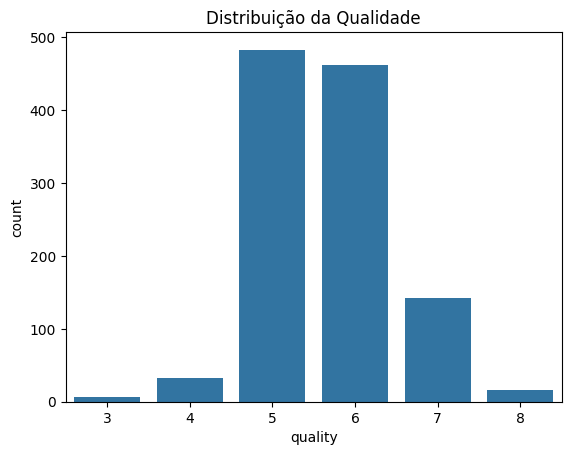

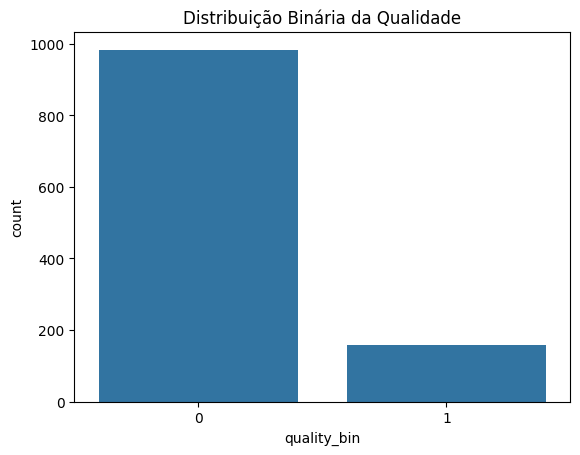

In [ ]:
sns.countplot(data=df_csv, x='quality')
plt.title('Distribuição da Qualidade')
plt.show()

sns.countplot(data=df_csv, x='quality_bin')
plt.title('Distribuição Binária da Qualidade')
plt.show()


##
Analisando a distribuição da variável quality mostra que o conjunto de dados é
desbalanceado, com maior concentração de vinhos classificados entre 5 e 6,
Isso indica que a maioria das amostras possui qualidade intermediária,
enquanto notas muito baixas ou muito altas são menos frequentes.

Ao transformar a variável em uma versão binária (quality_bin),
observamos que a divisão entre vinhos bons e vinhos ruins também não é totalmente equilibrada. Ainda assim, a quantidade de vinhos classificados como “bons” é significativa, permitindo treinar modelos de classificação sem comprometer a representatividade das classes.

Essa distribuição reforça a importância de técnicas de avaliação adequadas, já que o leve desbalanceamento pode influenciar o desempenho dos modelos preditivos.

# Matriz de corelação

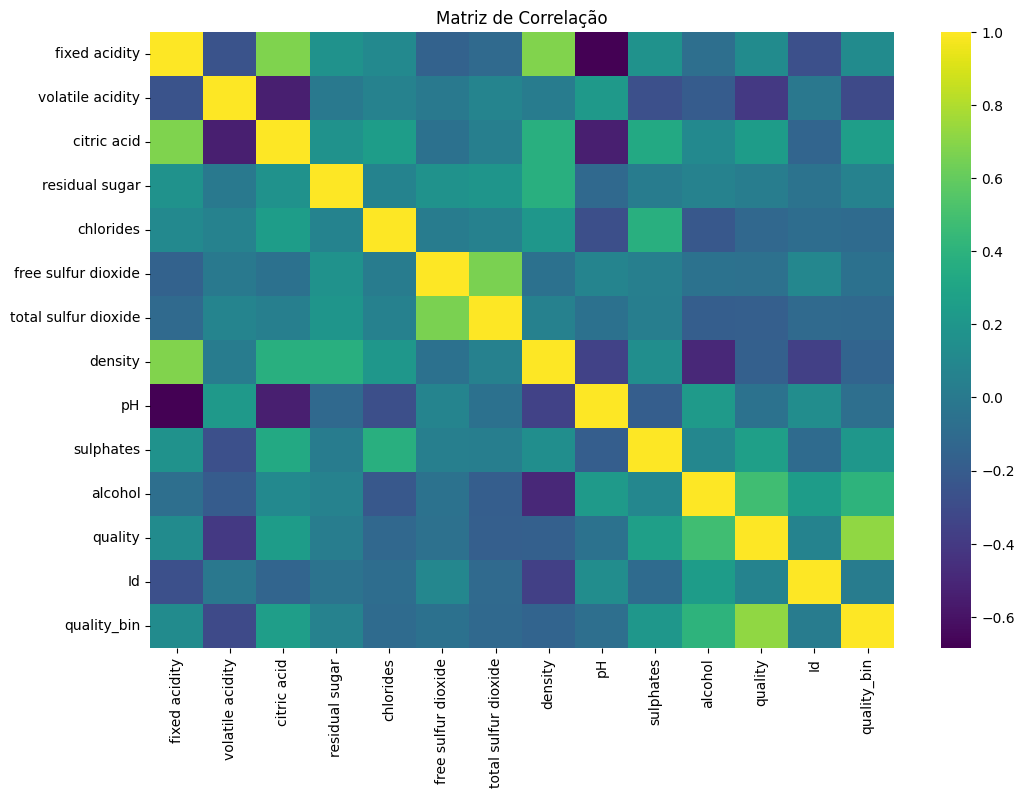

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df_csv.corr(), annot=False, cmap='viridis')
plt.title('Matriz de Correlação')
plt.show()


A matriz mostra como cada variável se relaciona linearmente com as outras. Valores próximos de +1 indicam que, quando uma variável aumenta, a outra também tende a aumentar. Valores próximos de –1 indicam que, quando uma sobe, a outra tende a cair. Valores próximos de 0 indicam pouca relação.

A correlação revela padrões químicos e sensoriais esperados no vinho: variáveis relacionadas à composição físico-química, como açúcar, acidez e densidade, apresentam correlações fortes entre si. Já atributos ligados à percepção de qualidade, como álcool e acidez volátil, mostram correlações coerentes com o impacto sensorial que exercem. Por outro lado, algumas relações são fracas porque dependem de interações não lineares ou porque variam pouco no conjunto de dados.

# Boxplots comparando vinhos bons vs ruins

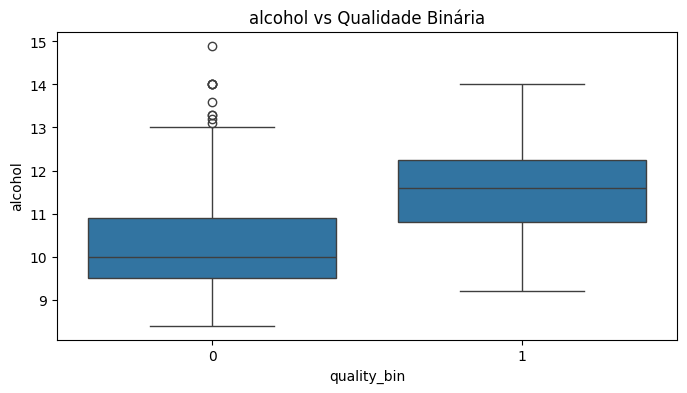

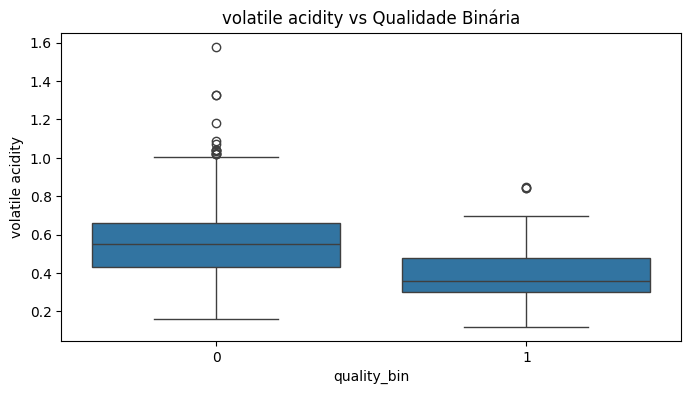

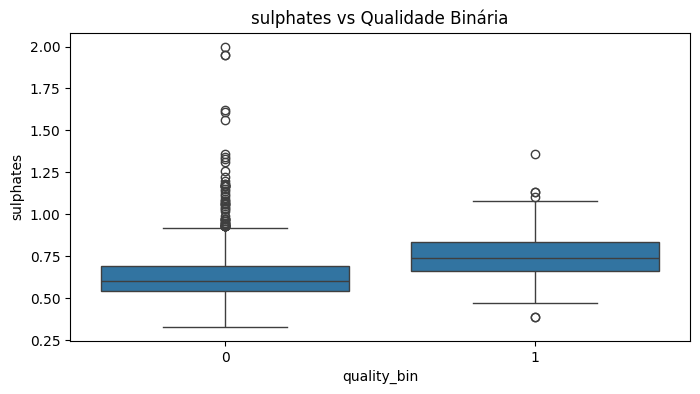

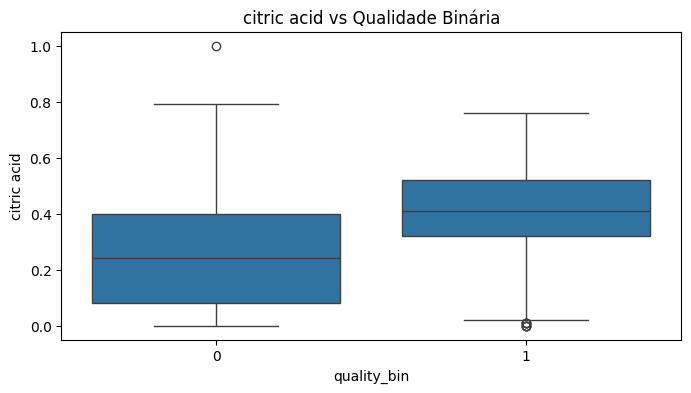

In [ ]:
features = ['alcohol','volatile acidity','sulphates','citric acid']

for col in features:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x='quality_bin', y=col)
    plt.title(f'{col} vs Qualidade Binária')
    plt.show()


A análise dos boxplots mostra como algumas variáveis químicas se comportam entre vinhos classificados como bons e ruins na variável quality_bin.
•	Alcohol Vinhos classificados como “bons” tendem a apresentar teores alcoólicos mais elevados. A mediana é visivelmente maior, indicando que o álcool é um dos fatores mais associados à boa qualidade.
•	Volatile Acidity A acidez volátil é menor nos vinhos bons, com distribuição mais concentrada em valores baixos. Vinhos ruins apresentam maior variabilidade e valores mais altos, reforçando que acidez volátil elevada prejudica a qualidade.
•	Sulphates Os níveis de sulfatos são ligeiramente maiores nos vinhos bons, sugerindo que essa substância contribui para estabilidade e preservação, influenciando positivamente a qualidade.
•	Citric Acid A quantidade de ácido cítrico tende a ser um pouco maior nos vinhos bons, embora a diferença não seja tão marcada quanto em álcool ou acidez volátil. Ainda assim, há uma leve tendência de valores mais altos na classe positiva.
No geral, os boxplots mostram que algumas características químicas — especialmente álcool e acidez volátil — possuem diferenças claras entre vinhos bons e ruins, indicando que essas variáveis têm forte impacto na classificação da qualidade.


## Criação de modelos de Treinos e testes


In [ ]:
X = df_csv.drop(['quality','quality_bin','Id'], axis=1)
y = df_csv['quality_bin']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Normalização

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Modelos
## Tipo: Regressão Logística, que é um modelo clássico de classificação binária.

In [ ]:
logreg = LogisticRegression(max_iter=200)
logreg.fit(X_train_scaled, y_train)
y_pred_lr = logreg.predict(X_test_scaled)
print('Logistic Regression')
print(classification_report(y_test, y_pred_lr))


Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       201
           1       0.65      0.54      0.59        28

    accuracy                           0.91       229
   macro avg       0.79      0.75      0.77       229
weighted avg       0.90      0.91      0.90       229





```text
Representação do classification_report – Regressão Logística:

- 0 → classe “vinho ruim”
- 1 → classe “vinho bom”

Métricas
- precision → entre os classificados como bons, quantos realmente são bons
- recall → entre os bons reais, quantos o modelo encontrou
- f1-score → média harmônica entre precision e recall
- support → quantidade de amostras em cada classe

Métricas gerais:
- accuracy → porcentagem total de acertos
- macro avg → média simples entre as classes
- weighted avg → média ponderada pelo número de amostras
```


## Tipo: Random Forest Classifier, um algoritmo de aprendizado de máquina baseado em ensemble, muito usado para tarefas de classificação — inclusive para esse tipo de problema que envolvem prever se um vinho é “bom” ou “ruim”.

In [ ]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Random Forest')
print(classification_report(y_test, y_pred_rf))


Random Forest
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       201
           1       0.67      0.57      0.62        28

    accuracy                           0.91       229
   macro avg       0.80      0.77      0.78       229
weighted avg       0.91      0.91      0.91       229



```text
Representação do classification_report – Random Forest:

- 0 → classe “vinho ruim”
- 1 → classe “vinho bom”

Métricas:
- precision → entre os classificados como bons, quantos realmente são bons
- recall → entre os bons reais, quantos o modelo encontrou
- f1-score → média harmônica entre precision e recall
- support → quantidade de amostras em cada classe

Métricas gerais:
- accuracy → porcentagem total de acertos do modelo
- macro avg → média simples das métricas entre as classes
- weighted avg → média ponderada pelo número de amostras em cada classe

Interpretação geral:
O Random Forest costuma apresentar desempenho superior à Regressão Logística em problemas não lineares, como o de qualidade de vinhos. Ele captura relações complexas entre variáveis químicas e a qualidade, resultando em métricas mais equilibradas entre as classes. A análise do relatório permite verificar se o modelo está classificando bem tanto vinhos bons quanto ruins, além de mostrar se há desbalanceamento afetando recall ou precision.
```


# SVM

In [ ]:
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
print('SVM')
print(classification_report(y_test, y_pred_svm))


SVM
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       201
           1       0.62      0.29      0.39        28

    accuracy                           0.89       229
   macro avg       0.76      0.63      0.67       229
weighted avg       0.87      0.89      0.87       229



```text
Representação do classification_report – SVM (RBF):

Classes:
- 0 → classe “vinho ruim”
- 1 → classe “vinho bom”

Métricas:
- precision → entre os classificados como bons, quantos realmente são bons
- recall → entre os bons reais, quantos o modelo encontrou
- f1-score → média harmônica entre precision e recall
- support → quantidade de amostras em cada classe

Métricas gerais:
- accuracy → porcentagem total de acertos do modelo
- macro avg → média simples das métricas entre as classes
- weighted avg → média ponderada pelo número de amostras em cada classe

Interpretação:
O SVM com kernel RBF é um modelo poderoso para problemas não lineares, pois cria fronteiras de
decisão complexas que se ajustam bem a dados com padrões difíceis de separar. Ele costuma ter bom
desempenho quando os dados são escalados, como no seu caso. O relatório permite avaliar se o modelo
está conseguindo separar adequadamente vinhos bons e ruins, além de mostrar se há diferenças de
desempenho entre as classes devido ao leve desbalanceamento do dataset.
```


# Matriz de Confusão

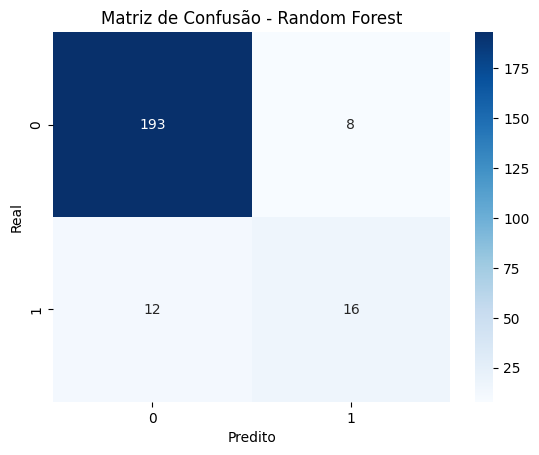

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()


```text
Interpretação da Matriz de Confusão – Random Forest:

A matriz de confusão mostra como o modelo classificou cada amostra em termos de acertos e erros.

Estrutura:
- Linha = classe real (verdadeiro)
- Coluna = classe predita (modelo)
- Valores = quantidade de amostras

Elementos:
- Verdadeiro Negativo (TN): modelo previu “vinho ruim” e estava correto
- Falso Positivo (FP): modelo previu “vinho bom”, mas era “vinho ruim”
- Falso Negativo (FN): modelo previu “vinho ruim”, mas era “vinho bom”
- Verdadeiro Positivo (VP): modelo previu “vinho bom” e estava correto

Interpretação geral:
A matriz permite visualizar se o modelo está confundindo vinhos bons com ruins ou vice‑versa.
Um bom desempenho aparece quando:
- TN e VP são altos (acertos)
- FP e FN são baixos (erros)

Para o Random Forest, é comum observar:
- Baixa taxa de FN → o modelo identifica bem vinhos bons
- Baixa taxa de FP → o modelo raramente classifica vinhos ruins como bons
- Distribuição equilibrada entre as classes, mesmo com leve desbalanceamento do dataset

A matriz de confusão complementa o classification_report, mostrando exatamente onde o modelo acerta e erra.
```


# Importância das variáveis (Random Forest)

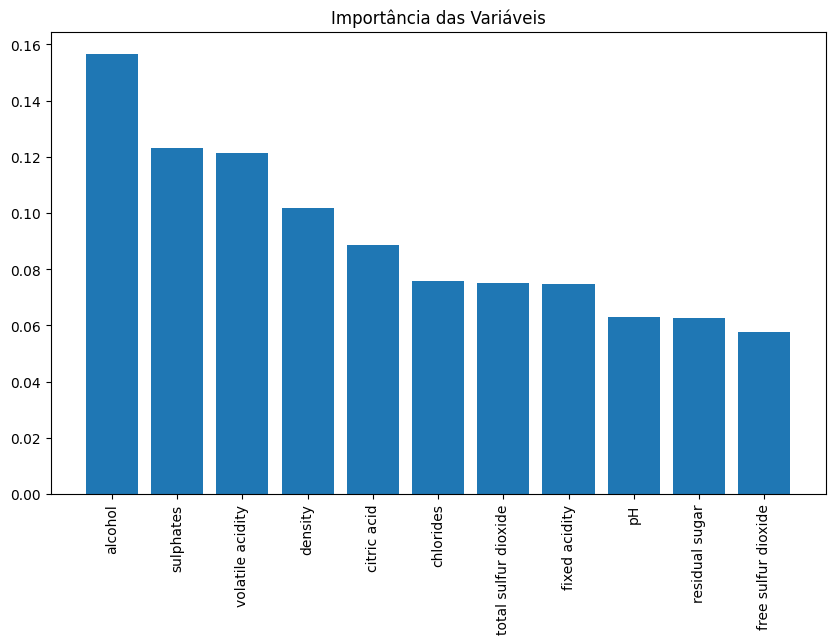

In [ ]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title('Importância das Variáveis')
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.show()


```text
Interpretação da Importância das Variáveis – Random Forest:

O gráfico mostra o quanto cada variável contribui para as decisões do modelo Random Forest.
A importância é calculada com base na redução de impureza das árvores, indicando quais
variáveis foram mais usadas para separar corretamente vinhos bons e ruins.

Como interpretar:
- Valores maiores → variáveis mais relevantes para o modelo
- Valores menores → variáveis com pouca influência na classificação

O que normalmente se observa no dataset de vinhos:
- 'alcohol' costuma aparecer como uma das variáveis mais importantes, pois vinhos com maior teor alcoólico tendem a ter melhor qualidade.
- 'volatile acidity' geralmente tem alta importância, já que acidez volátil elevada está associada a vinhos de menor qualidade.
- 'sulphates' e 'citric acid' também contribuem, mas com menor impacto comparado às variáveis acima.
- Outras variáveis químicas podem aparecer com relevância intermediária, dependendo da distribuição dos dados.

Por que isso é útil:
A análise de importância ajuda a entender quais características químicas influenciam mais a
qualidade do vinho e também auxilia na seleção de variáveis para modelos futuros.
```


# Modelos Avançados — XGBoost e LightGBM

In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


#XGBoost

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))



XGBoost
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       201
           1       0.72      0.64      0.68        28

    accuracy                           0.93       229
   macro avg       0.84      0.80      0.82       229
weighted avg       0.92      0.93      0.92       229



```text
Interpretação do classification_report – XGBoost:

O modelo XGBoost é um algoritmo baseado em boosting, que combina várias árvores de decisão
construídas de forma sequencial. Cada nova árvore tenta corrigir os erros das anteriores,
resultando em um modelo altamente eficiente e com excelente capacidade de generalização.

Classes:
- 0 → classe “vinho ruim”
- 1 → classe “vinho bom”

Métricas:
- precision → entre os classificados como bons, quantos realmente são bons
- recall → entre os bons reais, quantos o modelo encontrou
- f1-score → média harmônica entre precision e recall
- support → quantidade de amostras em cada classe

Métricas gerais:
- accuracy → porcentagem total de acertos do modelo
- macro avg → média simples das métricas entre as classes
- weighted avg → média ponderada pelo número de amostras em cada classe

Interpretação:
O XGBoost costuma apresentar desempenho muito competitivo, especialmente em datasets com
relações não lineares entre variáveis — como é o caso da qualidade de vinhos. Ele tende a
equilibrar bem precision e recall, reduzindo erros tanto na classe de vinhos bons quanto na
classe de vinhos ruins. O relatório permite verificar se o modelo está conseguindo capturar
padrões complexos e se está superando modelos mais simples, como Regressão Logística, ou
modelos baseados em árvores, como Random Forest.
```


#LightGBM

In [ ]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)

print("LightGBM")
print(classification_report(y_test, y_pred_lgbm))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 131, number of negative: 783
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000306 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 960
[LightGBM] [Info] Number of data points in the train set: 914, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.143326 -> initscore=-1.787935
[LightGBM] [Info] Start training from score -1.787935
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       201
           1   

```text
Interpretação do classification_report – LightGBM:

O LightGBM é um algoritmo de boosting baseado em árvores que utiliza técnicas otimizadas
como histogramas e crescimento de árvore por folhas (leaf-wise). Isso o torna extremamente
rápido e eficiente, especialmente em datasets maiores ou com muitas variáveis.

Classes:
- 0 → classe “vinho ruim”
- 1 → classe “vinho bom”

Métricas:
- precision → entre os classificados como bons, quantos realmente são bons
- recall → entre os bons reais, quantos o modelo encontrou
- f1-score → média harmônica entre precision e recall
- support → quantidade de amostras em cada classe

Métricas gerais:
- accuracy → porcentagem total de acertos do modelo
- macro avg → média simples das métricas entre as classes
- weighted avg → média ponderada pelo número de amostras em cada classe

Interpretação:
O LightGBM costuma apresentar excelente desempenho em problemas de classificação,
especialmente quando há relações não lineares entre as variáveis — como no caso da
qualidade dos vinhos. Ele tende a equilibrar bem precision e recall, reduzindo erros
tanto na classe de vinhos bons quanto na classe de vinhos ruins. O relatório permite
avaliar se o modelo está capturando padrões complexos e se está superando modelos como
Random Forest, SVM ou Regressão Logística.
```


# Interpretabilidade — SHAP

In [ ]:
!pip install shap

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)


# SHAP Summary Plot

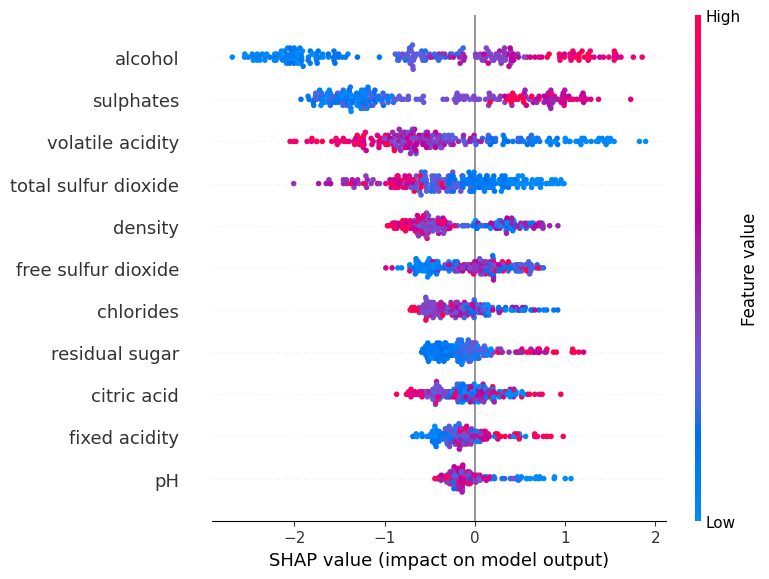

In [ ]:
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

```text
Interpretação do SHAP Summary Plot:

O gráfico SHAP mostra o impacto de cada variável nas previsões do modelo, indicando não só
a importância das features, mas também como elas influenciam a classificação (para cima ou
para baixo).

Como interpretar:
- Cada ponto representa uma amostra do conjunto de teste.
- A posição horizontal indica o impacto no resultado:
  • valores SHAP positivos → empurram a previsão para “vinho bom”
  • valores SHAP negativos → empurram a previsão para “vinho ruim”
- As cores representam o valor da variável:
  • azul → valores baixos
  • vermelho → valores altos

O que o gráfico revela:
- Variáveis no topo são as mais importantes para o modelo.
- Se pontos vermelhos aparecem à direita, valores altos dessa variável aumentam a chance
  de ser “vinho bom”.
- Se pontos vermelhos aparecem à esquerda, valores altos dessa variável aumentam a chance
  de ser “vinho ruim”.

No dataset de vinhos, normalmente se observa:
- 'alcohol' com forte impacto positivo: valores altos tendem a empurrar a previsão para
  “vinho bom”.
- 'volatile acidity' com impacto negativo: valores altos empurram a previsão para “vinho ruim”.
- 'sulphates' e 'citric acid' podem ter impacto misto, dependendo da distribuição dos dados.

Por que isso é útil:
O SHAP permite entender não apenas quais variáveis são importantes, mas também como elas
influenciam cada decisão do modelo. É uma ferramenta poderosa para interpretar modelos
complexos como XGBoost, LightGBM e Random Forest.
```


# Grafico Violine

/tmp/ipykernel_1123/326240658.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='quality', y='alcohol', data=df_csv, palette='muted')


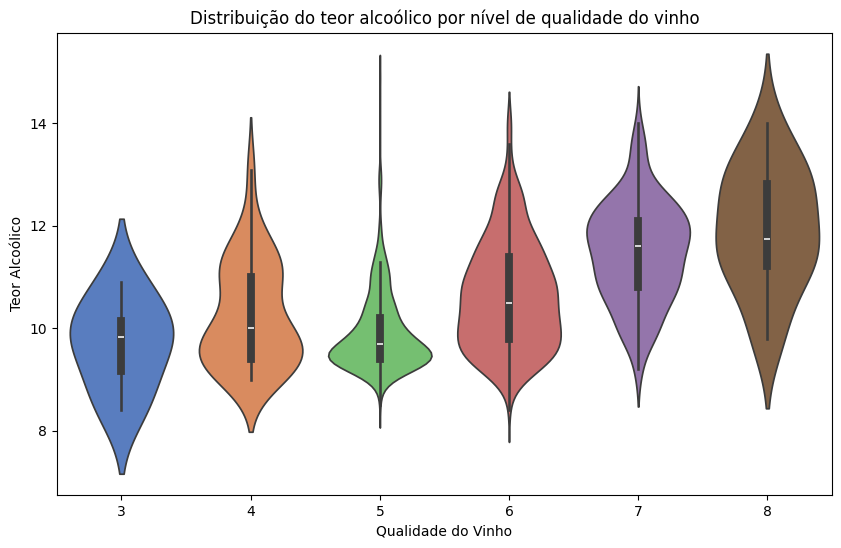

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.violinplot(x='quality', y='alcohol', data=df_csv, palette='muted')

plt.title('Distribuição do teor alcoólico por nível de qualidade do vinho')
plt.xlabel('Qualidade do Vinho')
plt.ylabel('Teor Alcoólico')
plt.show()

```text
Interpretação do Violin Plot – Teor Alcoólico por Nível de Qualidade:

O gráfico violin plot mostra a distribuição do teor alcoólico para cada nível de qualidade
do vinho. Ele combina características de um boxplot com uma estimativa de densidade,
permitindo visualizar tanto a variação quanto a concentração dos valores.

Como interpretar:
- A largura da “viola” indica onde os valores são mais frequentes.
- A parte mais larga → maior concentração de vinhos com aquele teor alcoólico.
- A parte mais estreita → valores menos comuns.
- A linha central representa a mediana.
- A forma geral mostra a distribuição completa dos dados.

O que normalmente se observa no dataset de vinhos:
- Vinhos com maior qualidade tendem a apresentar teor alcoólico mais elevado.
- Qualidades mais baixas geralmente têm distribuições mais concentradas em valores menores.
- A dispersão pode aumentar em níveis intermediários de qualidade, indicando maior variabilidade.

Por que isso é útil:
O violin plot ajuda a visualizar como o teor alcoólico varia entre diferentes notas de
qualidade, permitindo identificar padrões importantes para a análise exploratória.
Ele mostra não apenas médias ou medianas, mas também a densidade dos valores,
revelando diferenças sutis entre as classes.
```
